# RC-HAVOK Hyperparameter Sensitivity Study — Chua Circuit (PWL + Cubic)

**Purpose.** The locked base reproduction and cubic extension notebooks use one fixed
reservoir/HAVOK configuration:

`neurons=500, spectral_radius=0.9, connectivity=0.200, leakage=0.400, HAVOK rank=4`

This notebook tests how sensitive **Modified RC-HAVOK** performance is to each of these
hyperparameters, one factor at a time (OFAT), holding all others at the locked baseline value,
for both the PWL and Cubic Chua systems.

**Scope.** This is a standalone screening study. It does **not** modify the locked base/extension
notebooks. It does **not** add noise, denoising, LSTM/GRU/Transformer, or seed-stability loops —
those are separate, already-completed notebooks in this project.

**Wording conventions** (kept consistent with prior notebooks in this project):
- "supports" / "suggests" rather than "proves"
- "bounded double-scroll-like trajectory" rather than "confirmed chaos"
- report divergence explicitly rather than letting unstable runs distort mean/std

**Before a full run:** set `QUICK_TEST = False` in the Global Configuration cell below and
consider raising `N_SEEDS_PER_CONFIG` (10-20) for publication-quality statistics. The default
`QUICK_TEST = True` runs a short smoke-test version end-to-end in a few minutes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import sparse
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.utils.extmath import randomized_svd
from numpy.lib.stride_tricks import sliding_window_view
import time
import warnings
warnings.filterwarnings("ignore")


## 1. GLOBAL CONFIGURATION

In [2]:
# ---- Screening-run switch ----
# QUICK_TEST=True   -> true smoke test: short trajectory, 1 seed, reduced grids.
# QUICK_TEST=False  -> full sensitivity study; use this for reported results.
QUICK_TEST = True

if QUICK_TEST:
    T_END = 5.0
    N_SEEDS_PER_CONFIG = 1
else:
    T_END = 50.0          # screening length; confirm best configs at 200 s before final reporting
    N_SEEDS_PER_CONFIG = 10

DT = 0.001
BURN_IN = 2000
EVAL_FRACTION = 0.3

# ---- Chua parameters (locked, matches prior notebooks) ----
ALPHA = 9.0
BETA = 100.0 / 7.0
M0, M1 = -1.0/7.0, 2.0/7.0
INIT_STATE = [0.1, 0.2, 0.1]

# ---- Locked baseline reservoir / HAVOK configuration ----
BASELINE = dict(
    n_reservoir=500,
    spectral_radius=0.9,
    connectivity=0.200,
    leakage=0.400,
    havok_rank=4,
    input_scaling=np.array([0.1, 0.1], dtype=np.float32),  # matches Table-I style scaling
)

FULL_SWEEP_GRIDS = {
    "n_reservoir":      [100, 300, 500, 700, 1000],
    "spectral_radius":  [0.5, 0.7, 0.9, 1.1],
    "leakage":          [0.1, 0.3, 0.4, 0.6, 0.9],
    "connectivity":     [0.05, 0.1, 0.2, 0.4],
    "havok_rank":       [3, 4, 5, 6, 8, 10],
}

# Keep QUICK_TEST genuinely quick. The original notebook's QUICK_TEST still ran the full grid,
# which made even the smoke test impractically slow.
QUICK_SWEEP_GRIDS = {
    "n_reservoir":      [100, 500],
    "spectral_radius":  [0.7, 0.9],
    "leakage":          [0.3, 0.4],
    "connectivity":     [0.1, 0.2],
    "havok_rank":       [3, 4],
}

SWEEP_GRIDS = QUICK_SWEEP_GRIDS if QUICK_TEST else FULL_SWEEP_GRIDS
SYSTEMS = ["pwl", "cubic"]


## 2. CHUA SYSTEMS (clean, no noise)

In [3]:
def h_pwl(x):
    return M1 * x + 0.5 * (M0 - M1) * (np.abs(x + 1) - np.abs(x - 1))

def h_cubic(x):
    return (1.0/16.0) * x**3 - (1.0/6.0) * x

def chua_rhs(t, s, h_func):
    x, y, z = s
    dx = ALPHA * (y - h_func(x))
    dy = x - y + z
    dz = -BETA * y
    return [dx, dy, dz]

def generate_chua_data(system, t_end, dt):
    h_func = h_pwl if system == "pwl" else h_cubic
    t_eval = np.arange(0, t_end, dt)
    sol = solve_ivp(
        chua_rhs, [0, t_end], INIT_STATE, t_eval=t_eval,
        args=(h_func,), method="RK45", rtol=1e-9, atol=1e-9,
    )
    return t_eval, sol.y[0], sol.y[1], sol.y[2]

# Pre-generate the clean trajectories ONCE per system per T_END
# (independent of reservoir/HAVOK hyperparameters -- avoids
# recomputing the ODE solution inside every sweep iteration).
print("Generating clean Chua trajectories (PWL and Cubic)...")
SYS_DATA = {}
for sysname in SYSTEMS:
    _, x_clean, _, _ = generate_chua_data(sysname, T_END, DT)
    SYS_DATA[sysname] = x_clean
    print(f"  {sysname}: N={len(x_clean)} points, std={x_clean.std():.4f}")

Generating clean Chua trajectories (PWL and Cubic)...
  pwl: N=5000 points, std=0.3799
  cubic: N=5000 points, std=0.3762


## 3. RESERVOIR + HANKEL + HAVOK PIPELINE (parameterized)

In [4]:
def estimate_spectral_radius_power(Wr, n_iter=60, tol=1e-6):
    """Fast spectral-radius estimate for the nonnegative sparse reservoir matrix."""
    if Wr.nnz == 0:
        return 0.0
    n = Wr.shape[0]
    v = np.ones(n, dtype=np.float64) / np.sqrt(n)
    prev = 0.0
    for _ in range(n_iter):
        w = Wr @ v
        norm = np.linalg.norm(w)
        if norm < 1e-14:
            return 0.0
        v = w / norm
        lam = float(v @ (Wr @ v))
        if abs(lam - prev) < tol * max(1.0, abs(lam)):
            break
        prev = lam
    return abs(lam)

def create_reservoir(n_reservoir, connectivity, spectral_radius, seed):
    rng = np.random.default_rng(seed)
    Win = (2 * rng.random((n_reservoir, 2)) - 1).astype(np.float32)

    # Sparse reservoir is mathematically the same masked random reservoir,
    # but avoids extremely slow dense 500x500 / 1000x1000 matrix-vector loops.
    mask = rng.random((n_reservoir, n_reservoir)) < connectivity
    rows, cols = np.nonzero(mask)
    data = rng.random(len(rows)).astype(np.float32)
    Wr = sparse.csr_matrix((data, (rows, cols)), shape=(n_reservoir, n_reservoir), dtype=np.float32)

    radius = estimate_spectral_radius_power(Wr)
    if radius > 1e-12:
        Wr = Wr * (spectral_radius / radius)
    return Win, Wr.tocsr()

def run_reservoir(x, n_reservoir, connectivity, spectral_radius, leakage, seed, input_scaling):
    Win, Wr = create_reservoir(n_reservoir, connectivity, spectral_radius, seed)
    n = len(x)
    states = np.zeros((n, n_reservoir), dtype=np.float32)
    s = np.zeros(n_reservoir, dtype=np.float32)
    input_scaling = np.asarray(input_scaling, dtype=np.float32)
    for k in range(1, n):
        u = input_scaling * np.array([1.0, x[k]], dtype=np.float32)
        pre = Wr @ s + Win @ u
        # This follows the existing project convention / paper equation form.
        # If your locked notebooks use gamma*tanh(pre), keep them consistent instead.
        s = (1 - leakage) * s + np.tanh(pre).astype(np.float32)
        states[k] = s
    return states

def build_hankel(states, delays, obs_idx=0, burn_in=BURN_IN):
    g = states[burn_in:, obs_idx].astype(np.float64)
    g = g - g.mean()
    g = g / (g.std() + 1e-12)
    if len(g) <= delays:
        raise ValueError(f"Not enough post-burn-in samples ({len(g)}) for delays={delays}.")
    H = sliding_window_view(g, delays).T.copy()
    return H

def fit_havok(H, rank, dt):
    # Only the first `rank` temporal modes are needed. Randomized SVD is much faster
    # than full SVD for H with shape ~100 x 48,000 in the full sweep.
    rank_eff = min(rank, min(H.shape) - 1)
    if rank_eff < rank:
        raise ValueError(f"Requested rank={rank}, but Hankel shape={H.shape} only supports rank={rank_eff}.")
    U, S, Vt = randomized_svd(H, n_components=rank, n_iter=5, random_state=0)
    V = Vt.T[:, :rank]
    dV = np.gradient(V, dt, axis=0)
    X = V[:, :rank-1]
    forcing = V[:, rank-1]
    dX = dV[:, :rank-1]
    Theta = np.hstack([X, forcing.reshape(-1, 1)])
    Xi, *_ = np.linalg.lstsq(Theta, dX, rcond=None)
    A_mod = Xi[:rank-1, :].T
    B_mod = Xi[rank-1, :].T
    A_ori = np.round(A_mod)
    B_ori = np.round(B_mod)
    return A_mod, B_mod, A_ori, B_ori, X, forcing

def one_step_metrics(X, forcing, A, B):
    dX_true = np.gradient(X, DT, axis=0)
    dX_pred = X @ A.T + np.outer(forcing, B)
    y_true = dX_true.ravel()
    y_pred = dX_pred.ravel()
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

MAX_STATE_NORM = 1e3

def free_run_metrics(X, forcing, A, B, eval_fraction):
    n = X.shape[0]
    n_eval = max(int(n * eval_fraction), 10)
    start = n - n_eval
    Xhat = np.zeros((n_eval, X.shape[1]))
    Xhat[0] = X[start]
    diverged = False
    for k in range(1, n_eval):
        dx = A @ Xhat[k-1] + B * forcing[start + k - 1]
        Xhat[k] = Xhat[k-1] + dx * DT
        if not np.all(np.isfinite(Xhat[k])) or np.max(np.abs(Xhat[k])) > MAX_STATE_NORM:
            diverged = True
            break
    if diverged:
        return np.nan, np.nan, True
    y_true = X[start:start+n_eval]
    r2 = r2_score(y_true, Xhat)
    rmse = np.sqrt(mean_squared_error(y_true, Xhat))
    return r2, rmse, False

def run_one_config(system, n_reservoir, spectral_radius, connectivity, leakage,
                   havok_rank, input_scaling, seed, hankel_delays=None):
    x = SYS_DATA[system]
    if hankel_delays is None:
        hankel_delays = max(havok_rank * 25, 100)
    states = run_reservoir(x, n_reservoir, connectivity, spectral_radius, leakage, seed, input_scaling)
    H = build_hankel(states, delays=hankel_delays)
    A_mod, B_mod, A_ori, B_ori, X, forcing = fit_havok(H, rank=havok_rank, dt=DT)
    r2_mod_1step, rmse_mod_1step = one_step_metrics(X, forcing, A_mod, B_mod)
    r2_ori_1step, rmse_ori_1step = one_step_metrics(X, forcing, A_ori, B_ori)
    r2_mod_free, rmse_mod_free, div_mod = free_run_metrics(X, forcing, A_mod, B_mod, EVAL_FRACTION)
    r2_ori_free, rmse_ori_free, div_ori = free_run_metrics(X, forcing, A_ori, B_ori, EVAL_FRACTION)
    return dict(
        r2_mod_1step=r2_mod_1step, rmse_mod_1step=rmse_mod_1step,
        r2_ori_1step=r2_ori_1step, rmse_ori_1step=rmse_ori_1step,
        r2_mod_free=r2_mod_free, rmse_mod_free=rmse_mod_free,
        r2_ori_free=r2_ori_free, rmse_ori_free=rmse_ori_free,
        max_abs_B_mod=np.max(np.abs(B_mod)),
        diverged_mod=div_mod, diverged_ori=div_ori,
    )

print("\n" + "="*60)
print("BASELINE SANITY CHECK (seed=42, T_END=%.0fs)" % T_END)
print("="*60)
for sysname in SYSTEMS:
    res = run_one_config(sysname, seed=42, **BASELINE)
    print(f"{sysname.upper():6s}  Modified free-run R2={res['r2_mod_free']:.5f}  "
          f"Original free-run R2={res['r2_ori_free']:.5f}")



BASELINE SANITY CHECK (seed=42, T_END=5s)


PWL     Modified free-run R2=0.62270  Original free-run R2=0.55808


CUBIC   Modified free-run R2=0.95447  Original free-run R2=0.95560


## 5. ONE-FACTOR-AT-A-TIME SENSITIVITY SWEEP

In [5]:
def robust_agg(vals, diverged_flags):
    vals = np.asarray(vals, dtype=float)
    diverged_flags = np.asarray(diverged_flags, dtype=bool)
    diverged_fraction = diverged_flags.mean()
    finite_vals = vals[~diverged_flags]
    finite_vals = finite_vals[np.isfinite(finite_vals)]
    if len(finite_vals) == 0:
        return dict(median=np.nan, q25=np.nan, q75=np.nan,
                    diverged_fraction=diverged_fraction, n_valid=0)
    return dict(
        median=np.median(finite_vals),
        q25=np.percentile(finite_vals, 25),
        q75=np.percentile(finite_vals, 75),
        diverged_fraction=diverged_fraction,
        n_valid=len(finite_vals),
    )

def failed_result():
    return dict(
        r2_mod_1step=np.nan, rmse_mod_1step=np.nan,
        r2_ori_1step=np.nan, rmse_ori_1step=np.nan,
        r2_mod_free=np.nan, rmse_mod_free=np.nan,
        r2_ori_free=np.nan, rmse_ori_free=np.nan,
        max_abs_B_mod=np.nan,
        diverged_mod=True, diverged_ori=True,
    )

def run_sweep(param_name, values, systems=SYSTEMS, n_seeds=N_SEEDS_PER_CONFIG):
    rows = []
    for sysname in systems:
        for val in values:
            cfg = dict(BASELINE)
            cfg[param_name] = val
            t0 = time.time()
            seed_results = []
            failures = 0
            for seed in range(n_seeds):
                try:
                    res = run_one_config(sysname, seed=seed, **cfg)
                except Exception as exc:
                    failures += 1
                    res = failed_result()
                    res["error"] = repr(exc)
                seed_results.append(res)
            runtime = time.time() - t0
            agg = {"system": sysname, "param": param_name, "value": val,
                   "n_seeds": n_seeds, "runtime_s": runtime, "n_failures": failures}

            for key in ["r2_mod_1step", "rmse_mod_1step", "r2_ori_1step", "rmse_ori_1step", "max_abs_B_mod"]:
                vv = np.array([r[key] for r in seed_results], dtype=float)
                agg[f"{key}_mean"] = np.nanmean(vv)
                agg[f"{key}_std"] = np.nanstd(vv)

            for key, div_key in [("r2_mod_free", "diverged_mod"), ("rmse_mod_free", "diverged_mod"),
                                 ("r2_ori_free", "diverged_ori"), ("rmse_ori_free", "diverged_ori")]:
                vv = [r[key] for r in seed_results]
                dv = [r[div_key] for r in seed_results]
                stats = robust_agg(vv, dv)
                agg[f"{key}_median"] = stats["median"]
                agg[f"{key}_q25"] = stats["q25"]
                agg[f"{key}_q75"] = stats["q75"]
                agg[f"{key}_diverged_frac"] = stats["diverged_fraction"]
                agg[f"{key}_n_valid"] = stats["n_valid"]

            rows.append(agg)
            print(f"  [{param_name}={val}, {sysname}] "
                  f"Modified free-run R2 median={agg['r2_mod_free_median']:.4f} "
                  f"(diverged {agg['r2_mod_free_diverged_frac']*100:.0f}% of seeds, "
                  f"failures={failures})  ({runtime:.1f}s, {n_seeds} seeds)")
    return pd.DataFrame(rows)

print("\n" + "="*60)
print("RUNNING SENSITIVITY SWEEPS")
print("="*60)

sweep_results = {}
for param_name, values in SWEEP_GRIDS.items():
    print(f"\n--- Sweeping {param_name}: {values} ---")
    sweep_results[param_name] = run_sweep(param_name, values)



RUNNING SENSITIVITY SWEEPS

--- Sweeping n_reservoir: [100, 500] ---
  [n_reservoir=100, pwl] Modified free-run R2 median=0.7107 (diverged 0% of seeds, failures=0)  (0.1s, 1 seeds)


  [n_reservoir=500, pwl] Modified free-run R2 median=0.3197 (diverged 0% of seeds, failures=0)  (0.4s, 1 seeds)


  [n_reservoir=100, cubic] Modified free-run R2 median=0.9980 (diverged 0% of seeds, failures=0)  (0.2s, 1 seeds)


  [n_reservoir=500, cubic] Modified free-run R2 median=0.9933 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)

--- Sweeping spectral_radius: [0.7, 0.9] ---


  [spectral_radius=0.7, pwl] Modified free-run R2 median=0.9804 (diverged 0% of seeds, failures=0)  (0.2s, 1 seeds)


...

  [connectivity=0.2, cubic] Modified free-run R2 median=0.9933 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)

--- Sweeping havok_rank: [3, 4] ---


  [havok_rank=3, pwl] Modified free-run R2 median=1.0000 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)


  [havok_rank=4, pwl] Modified free-run R2 median=0.3197 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)


  [havok_rank=3, cubic] Modified free-run R2 median=1.0000 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)


  [havok_rank=4, cubic] Modified free-run R2 median=0.9933 (diverged 0% of seeds, failures=0)  (0.3s, 1 seeds)


## 6. RESULTS TABLES


COMBINED SENSITIVITY RESULTS (head)
system           param  value  r2_mod_free_median  r2_mod_free_diverged_frac  r2_ori_free_median  r2_ori_free_diverged_frac
   pwl     n_reservoir  100.0            0.710706                        0.0            0.839149                        0.0
   pwl     n_reservoir  500.0            0.319737                        0.0            0.543592                        0.0
 cubic     n_reservoir  100.0            0.997989                        0.0            0.976584                        0.0
 cubic     n_reservoir  500.0            0.993335                        0.0            0.969167                        0.0
   pwl spectral_radius    0.7            0.980367                        0.0            0.992052                        0.0
   pwl spectral_radius    0.9            0.319737                        0.0            0.543592                        0.0
 cubic spectral_radius    0.7            0.999907                        0.0            0.97707

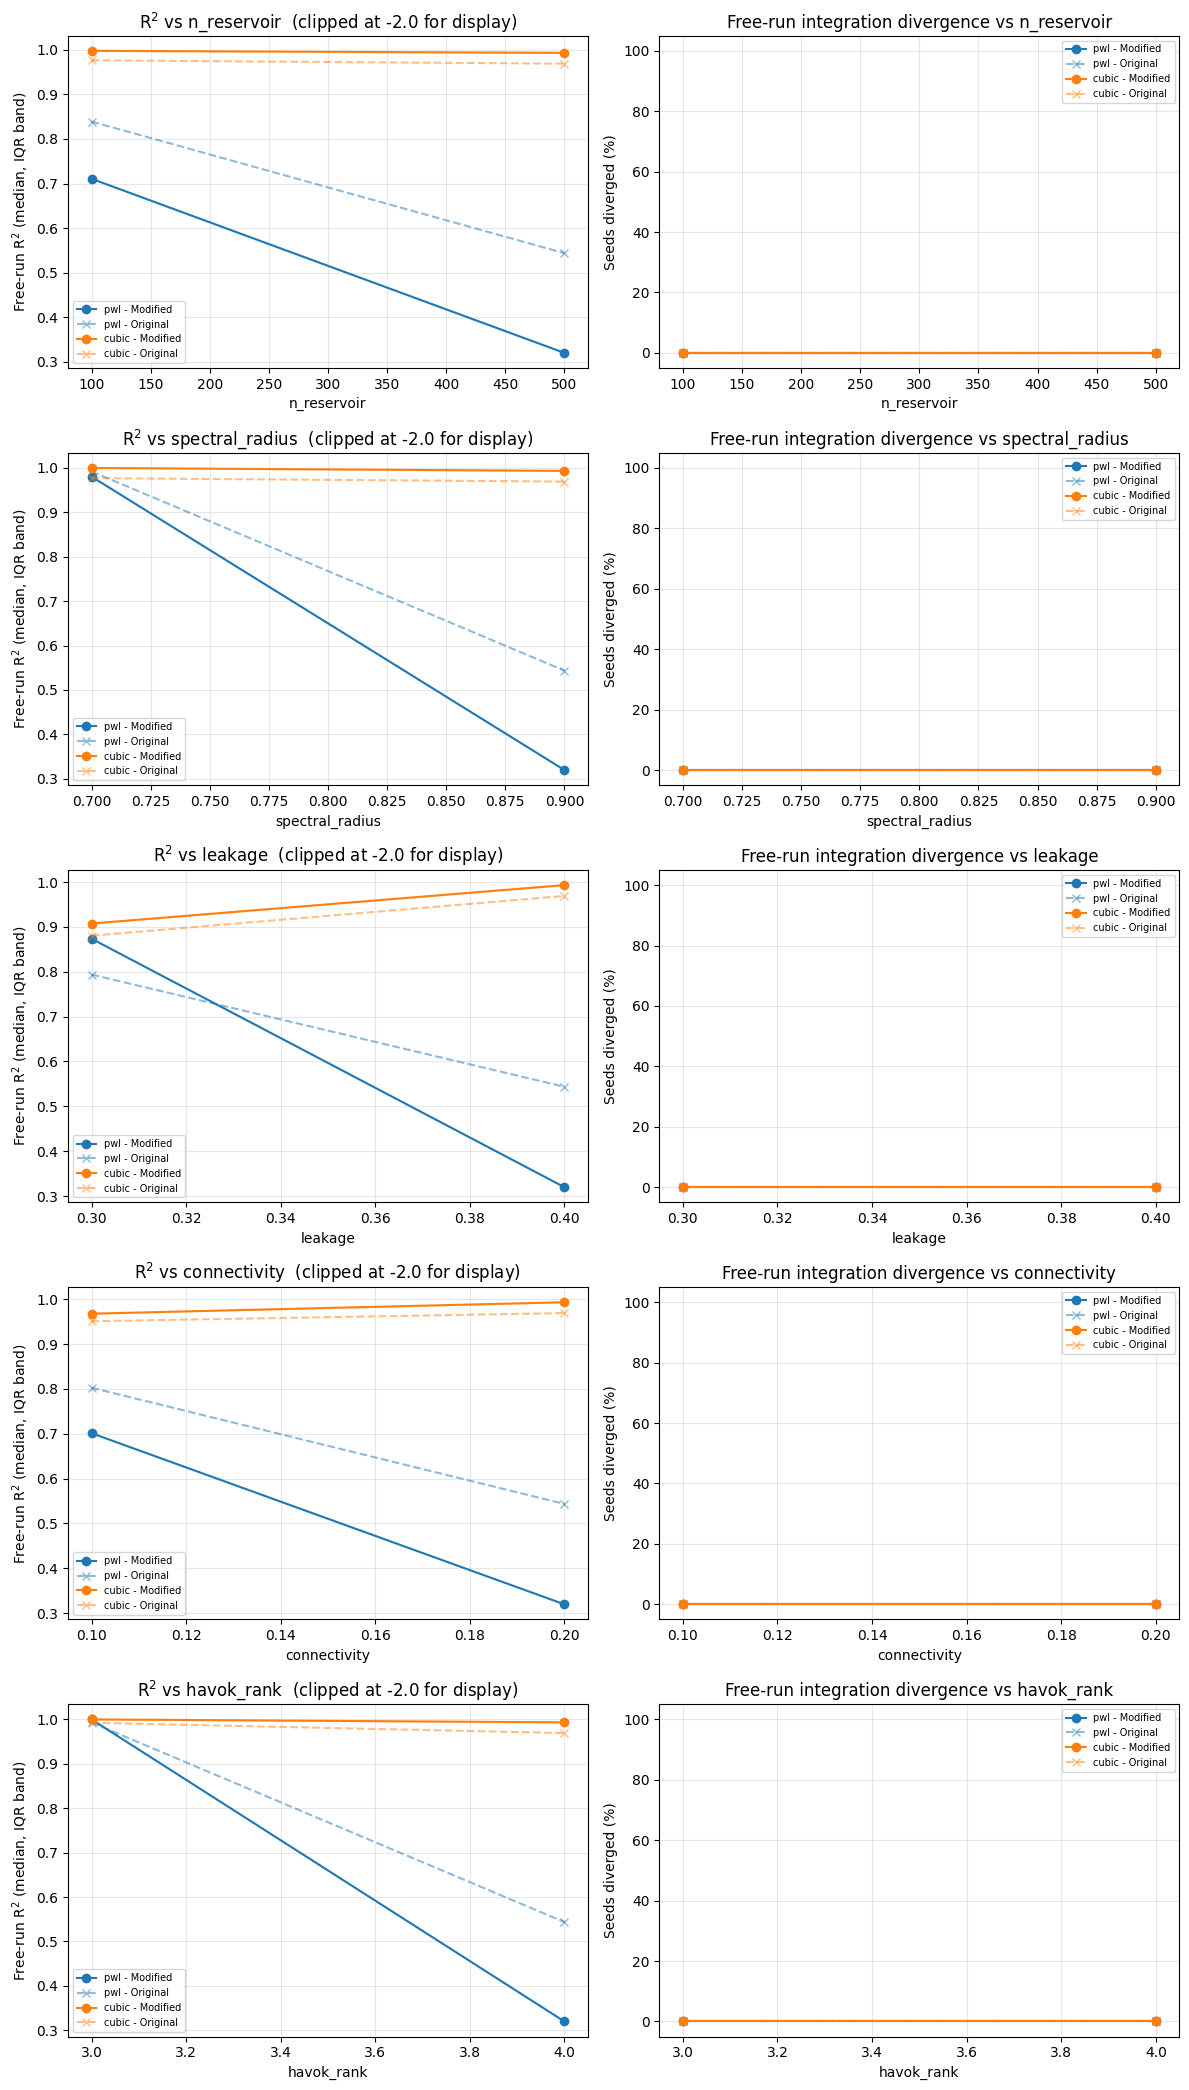

Saved: sensitivity_r2_plots.png
Note: R^2 values below -2.0 are clipped for readability in the plot only; true (unclipped) values are in the exported Excel file.


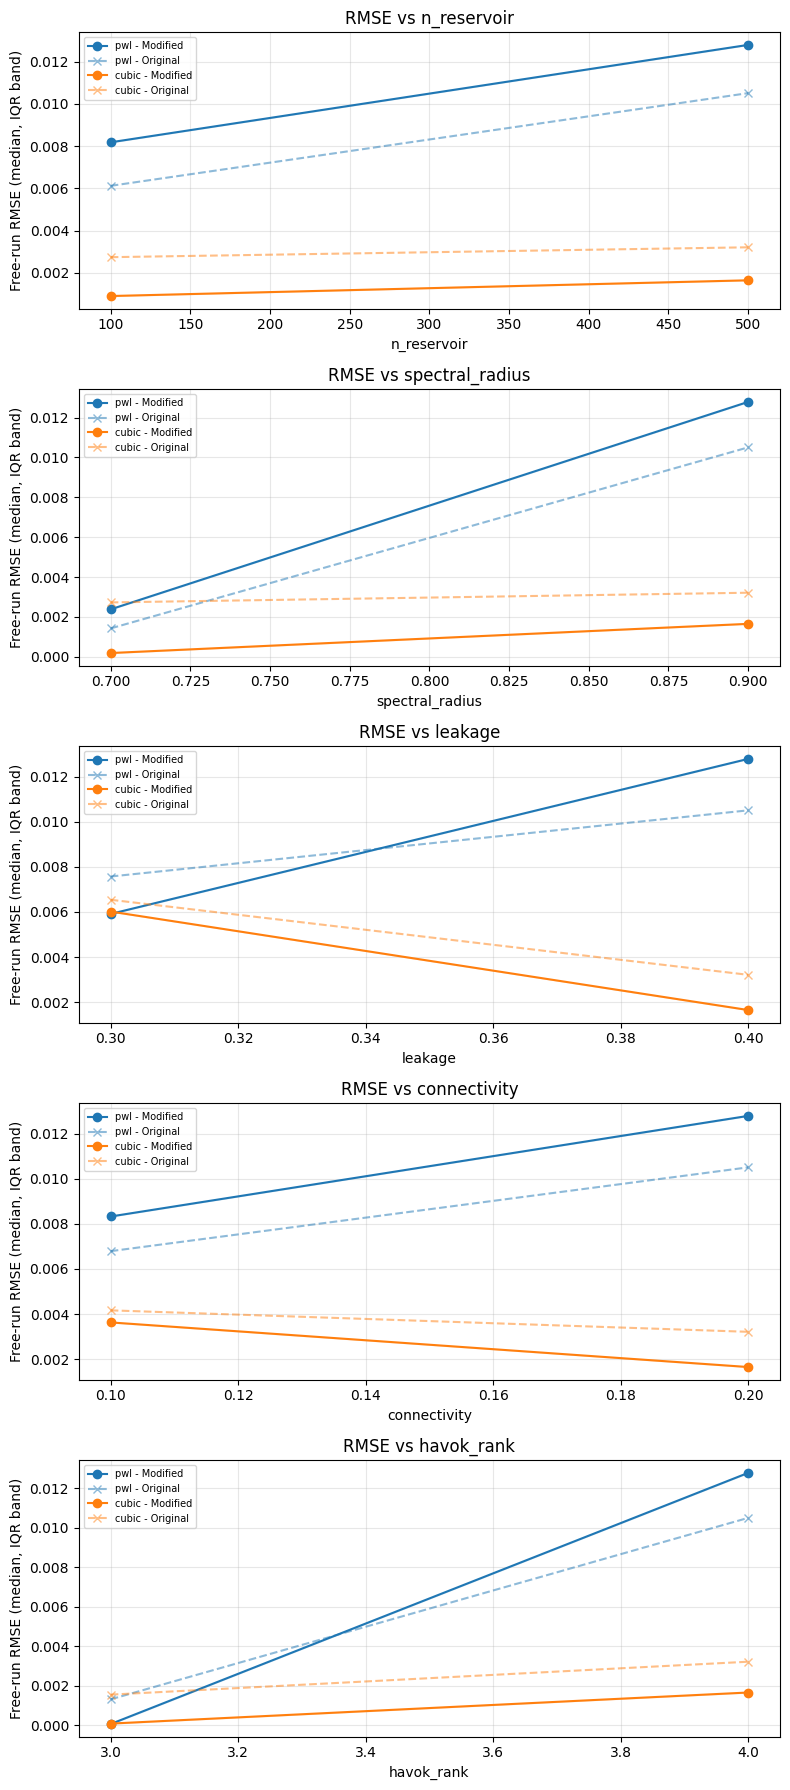

Saved: sensitivity_rmse_plots.png


In [6]:
all_sweeps_df = pd.concat(sweep_results.values(), ignore_index=True)
print("\n" + "="*60)
print("COMBINED SENSITIVITY RESULTS (head)")
print("="*60)
print(all_sweeps_df[["system", "param", "value",
                      "r2_mod_free_median", "r2_mod_free_diverged_frac",
                      "r2_ori_free_median", "r2_ori_free_diverged_frac"]].to_string(index=False))

# ============================================================
# 7. PLOTS: R^2 (free-run) vs each parameter, PWL vs Cubic,
#    Modified vs Original, with error bars (mean +/- std)
# ============================================================

R2_DISPLAY_FLOOR = -2.0  # clip only for readability; raw values kept in the Excel export

def clip_for_display(s):
    return np.clip(s, R2_DISPLAY_FLOOR, 1.05)

fig, axes = plt.subplots(len(SWEEP_GRIDS), 2, figsize=(12, 4.2*len(SWEEP_GRIDS)))
for row, (param_name, values) in enumerate(SWEEP_GRIDS.items()):
    df = sweep_results[param_name]
    ax_r2, ax_div = axes[row]
    for sysname, color in zip(SYSTEMS, ["tab:blue", "tab:orange"]):
        sub = df[df["system"] == sysname].sort_values("value")
        med = clip_for_display(sub["r2_mod_free_median"])
        q25 = clip_for_display(sub["r2_mod_free_q25"])
        q75 = clip_for_display(sub["r2_mod_free_q75"])
        ax_r2.plot(sub["value"], med, marker="o", label=f"{sysname} - Modified", color=color)
        ax_r2.fill_between(sub["value"], q25, q75, color=color, alpha=0.2)
        ax_r2.plot(sub["value"], clip_for_display(sub["r2_ori_free_median"]),
                   marker="x", linestyle="--", label=f"{sysname} - Original",
                   color=color, alpha=0.5)
        ax_div.plot(sub["value"], sub["r2_mod_free_diverged_frac"]*100, marker="o",
                    label=f"{sysname} - Modified", color=color)
        ax_div.plot(sub["value"], sub["r2_ori_free_diverged_frac"]*100, marker="x",
                    linestyle="--", label=f"{sysname} - Original", color=color, alpha=0.5)
    ax_r2.set_xlabel(param_name)
    ax_r2.set_ylabel("Free-run R$^2$ (median, IQR band)")
    ax_r2.set_title(f"R$^2$ vs {param_name}  (clipped at {R2_DISPLAY_FLOOR} for display)")
    ax_r2.legend(fontsize=7)
    ax_r2.grid(alpha=0.3)

    ax_div.set_xlabel(param_name)
    ax_div.set_ylabel("Seeds diverged (%)")
    ax_div.set_title(f"Free-run integration divergence vs {param_name}")
    ax_div.set_ylim(-5, 105)
    ax_div.legend(fontsize=7)
    ax_div.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sensitivity_r2_plots.png", dpi=120)
plt.show()
print("Saved: sensitivity_r2_plots.png")
print(f"Note: R^2 values below {R2_DISPLAY_FLOOR} are clipped for readability in the plot only; "
      f"true (unclipped) values are in the exported Excel file.")

# RMSE plots are separate because RMSE has a different scale from R^2.
fig, axes = plt.subplots(len(SWEEP_GRIDS), 1, figsize=(8, 3.6*len(SWEEP_GRIDS)))
if len(SWEEP_GRIDS) == 1:
    axes = [axes]
for ax, (param_name, values) in zip(axes, SWEEP_GRIDS.items()):
    df = sweep_results[param_name]
    for sysname, color in zip(SYSTEMS, ["tab:blue", "tab:orange"]):
        sub = df[df["system"] == sysname].sort_values("value")
        med = sub["rmse_mod_free_median"]
        q25 = sub["rmse_mod_free_q25"]
        q75 = sub["rmse_mod_free_q75"]
        ax.plot(sub["value"], med, marker="o", label=f"{sysname} - Modified", color=color)
        ax.fill_between(sub["value"], q25, q75, color=color, alpha=0.2)
        ax.plot(sub["value"], sub["rmse_ori_free_median"], marker="x", linestyle="--",
                label=f"{sysname} - Original", color=color, alpha=0.5)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Free-run RMSE (median, IQR band)")
    ax.set_title(f"RMSE vs {param_name}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sensitivity_rmse_plots.png", dpi=120)
plt.show()
print("Saved: sensitivity_rmse_plots.png")


## 8. MOST-SENSITIVE-PARAMETER SUMMARY

In [7]:
print("\n" + "="*60)
print("SENSITIVITY RANKING (Modified RC-HAVOK, both systems)")
print("="*60)
sensitivity_summary = []
for param_name in SWEEP_GRIDS:
    df = sweep_results[param_name]
    row = {"param": param_name}
    for sysname in SYSTEMS:
        sub = df[df["system"] == sysname]
        finite_medians = sub["r2_mod_free_median"].replace([np.inf, -np.inf], np.nan).dropna()
        r2_range = (finite_medians.max() - finite_medians.min()) if len(finite_medians) else np.nan
        max_diverged_frac = sub["r2_mod_free_diverged_frac"].max()
        row[f"r2_median_range_{sysname}"] = r2_range
        row[f"max_diverged_frac_{sysname}"] = max_diverged_frac
    sensitivity_summary.append(row)
sens_df = pd.DataFrame(sensitivity_summary).sort_values(
    "r2_median_range_pwl", ascending=False)
print(sens_df.to_string(index=False))
print("\nLarger r2_median_range = median performance swings more across the tested "
      "range (fragile hyperparameter). Larger max_diverged_frac = at least one "
      "tested value causes free-run instability in a large share of seeds.")


SENSITIVITY RANKING (Modified RC-HAVOK, both systems)
          param  r2_median_range_pwl  max_diverged_frac_pwl  r2_median_range_cubic  max_diverged_frac_cubic
     havok_rank             0.680232                    0.0               0.006628                      0.0
spectral_radius             0.660630                    0.0               0.006572                      0.0
        leakage             0.554061                    0.0               0.085673                      0.0
    n_reservoir             0.390969                    0.0               0.004653                      0.0
   connectivity             0.381642                    0.0               0.025498                      0.0

Larger r2_median_range = median performance swings more across the tested range (fragile hyperparameter). Larger max_diverged_frac = at least one tested value causes free-run instability in a large share of seeds.


## 9. EXPORT

In [8]:
all_sweeps_df.to_excel("RC_HAVOK_Hyperparameter_Sensitivity_Results.xlsx", index=False)
sens_df.to_excel("RC_HAVOK_Sensitivity_Ranking.xlsx", index=False)
print("\nSaved: RC_HAVOK_Hyperparameter_Sensitivity_Results.xlsx")
print("Saved: RC_HAVOK_Sensitivity_Ranking.xlsx")


Saved: RC_HAVOK_Hyperparameter_Sensitivity_Results.xlsx
Saved: RC_HAVOK_Sensitivity_Ranking.xlsx


## 10. INTERPRETATION (fill in after a full, non-QUICK_TEST run)

In [9]:
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
This screening study varies one RC-HAVOK hyperparameter at a time
(reservoir size, spectral radius, leakage rate, connectivity, and
HAVOK rank) while holding the others at the locked baseline
(neurons=500, spectral_radius=0.9, connectivity=0.200, leakage=0.400,
rank=4), for both the PWL and Cubic Chua systems.

Report, for each parameter:
  - whether Modified RC-HAVOK R^2 stays high (>0.9) across the full
    tested range (=> the locked baseline is not a fragile choice), or
  - whether R^2 degrades sharply outside a narrow band (=> that
    hyperparameter should be called out as a design-sensitive choice
    in the paper's Methodology / Limitations section).

Use "suggests" / "is sensitive to" rather than "proves optimal",
since this is a bounded OFAT screen, not a full factorial search,
and (if QUICK_TEST or a shortened T_END was used) results here should
be re-confirmed at full trajectory length (200 s, matching the base
reproduction) before being reported as final in the paper.
""")

print("DONE.")


INTERPRETATION

This screening study varies one RC-HAVOK hyperparameter at a time
(reservoir size, spectral radius, leakage rate, connectivity, and
HAVOK rank) while holding the others at the locked baseline
(neurons=500, spectral_radius=0.9, connectivity=0.200, leakage=0.400,
rank=4), for both the PWL and Cubic Chua systems.

Report, for each parameter:
  - whether Modified RC-HAVOK R^2 stays high (>0.9) across the full
    tested range (=> the locked baseline is not a fragile choice), or
  - whether R^2 degrades sharply outside a narrow band (=> that
    hyperparameter should be called out as a design-sensitive choice
    in the paper's Methodology / Limitations section).

Use "suggests" / "is sensitive to" rather than "proves optimal",
since this is a bounded OFAT screen, not a full factorial search,
and (if QUICK_TEST or a shortened T_END was used) results here should
be re-confirmed at full trajectory length (200 s, matching the base
reproduction) before being reported as final i